# Chapter 15: Principal Component Analysis (PCA)

## Summary

Principal Component Analysis (PCA) is one of the most widely used dimensionality reduction techniques in machine learning and data science.

PCA transforms high-dimensional data into a smaller number of variables called principal components while preserving as much information as possible.

PCA is closely related to eigendecomposition and Singular Value Decomposition (SVD).

## Learning Objectives

After completing this chapter, students should be able to:

- Understand the purpose of PCA.
- Explain principal components.
- Compute PCA using Python.
- Interpret explained variance.
- Reduce dimensionality using PCA.
- Understand PCA applications in machine learning.

## Theory: Why Dimensionality Reduction?

Many datasets contain numerous features.

High-dimensional datasets can cause:

- Increased computational cost
- Overfitting
- Difficult visualization
- Redundant information

Dimensionality reduction addresses these problems by representing data using fewer variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2,1],
    [3,2],
    [4,3],
    [5,4],
    [6,5]
])

print(X)


[[2 1]
 [3 2]
 [4 3]
 [5 4]
 [6 5]]


## Code Explanation

The dataset contains two correlated features.

PCA will identify the most important direction of variation within this dataset.

## Theory: Principal Components

Principal components are new variables created from linear combinations of the original features.

Properties:

- Components are uncorrelated.
- Components capture maximum variance.
- Components are ordered by importance.

The first principal component captures the greatest amount of variance.

In [2]:
X_centered = X - np.mean(
    X,
    axis=0
)

print(X_centered)

[[-2. -2.]
 [-1. -1.]
 [ 0.  0.]
 [ 1.  1.]
 [ 2.  2.]]


## Theory: Data Centering

Before performing PCA, data is typically centered by subtracting the mean.

Centering ensures that PCA focuses on variance rather than absolute values.

In [3]:
cov_matrix = np.cov(
    X_centered.T
)

print(cov_matrix)

[[2.5 2.5]
 [2.5 2.5]]


## Theory: Covariance Matrix

The covariance matrix describes relationships between variables.

PCA analyzes the covariance matrix to identify directions with maximum variance.

Eigenvectors of the covariance matrix become principal components.

In [4]:
eigenvalues, eigenvectors = np.linalg.eig(
    cov_matrix
)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[5.0000000e+00 4.4408921e-16]

Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## Code Explanation

The eigenvalues indicate how much variance is explained by each component.

The eigenvectors define the directions of the principal components.

## Theory: Explained Variance

Explained variance measures how much information is retained by each principal component.

Components with larger eigenvalues explain more variance and are generally more important.

In [5]:
explained_variance_ratio = (
    eigenvalues /
    np.sum(eigenvalues)
)

print(explained_variance_ratio)

[1.0000000e+00 8.8817842e-17]


## Theory: Selecting Principal Components

A common PCA objective is to retain most of the variance while reducing the number of features.

Often, only the first few principal components are needed to preserve most of the information.

In [6]:
principal_component = eigenvectors[:,0]

print(principal_component)

[0.70710678 0.70710678]


## Code Explanation

The first principal component corresponds to the eigenvector associated with the largest eigenvalue.

This component captures the most important direction in the dataset.

In [7]:
projected_data = X_centered @ principal_component

print(projected_data)

[-2.82842712 -1.41421356  0.          1.41421356  2.82842712]


## Applications in Data Science

PCA is widely used in:

- Feature Reduction
- Data Visualization
- Noise Reduction
- Computer Vision
- Bioinformatics
- Recommendation Systems

It helps simplify complex datasets while retaining useful information.

## Discussion

PCA reduces data complexity by identifying directions that capture the greatest variation.

This approach improves computational efficiency and often enhances model performance by removing redundant information.

## Theory: Data Projection

After identifying principal components, the original data can be projected onto these new axes.

Projection transforms the original feature space into a lower-dimensional representation while preserving the most important information.

This is the core idea behind dimensionality reduction.

In [8]:
first_pc = eigenvectors[:, np.argmax(eigenvalues)]

projected_data = X_centered @ first_pc

print(projected_data)

[-2.82842712 -1.41421356  0.          1.41421356  2.82842712]


## Code Explanation

The dataset is projected onto the first principal component.

Each value represents the coordinate of an observation along the most informative direction in the dataset.

## Theory: PCA Reconstruction

Although PCA reduces dimensionality, it is possible to approximately reconstruct the original data.

The reconstructed data will not be identical if some components were removed, but it should preserve the main structure of the dataset.

In [9]:
reconstructed_data = np.outer(
    projected_data,
    first_pc
)

reconstructed_data += np.mean(
    X,
    axis=0
)

print(reconstructed_data)

[[2. 1.]
 [3. 2.]
 [4. 3.]
 [5. 4.]
 [6. 5.]]


## Code Explanation

The reconstruction is obtained by projecting the reduced representation back into the original feature space.

Some information may be lost, but the main patterns remain.

## Theory: PCA Using Scikit-Learn

Scikit-Learn provides a convenient PCA implementation.

The library automatically computes principal components and explained variance.

This is the most common approach used in machine learning projects.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

X_pca = pca.fit_transform(X)

print(X_pca)

[[ 2.82842712]
 [ 1.41421356]
 [-0.        ]
 [-1.41421356]
 [-2.82842712]]


## Code Explanation

The PCA model reduces the dataset from two dimensions to one dimension.

The transformed dataset retains the most important information while reducing complexity.

In [11]:
print(
    pca.explained_variance_ratio_
)

[1.]


## Theory: Explained Variance Ratio

The explained variance ratio indicates the proportion of total variance captured by each principal component.

Higher values indicate more informative components.

This metric helps determine how many components should be retained.

In [12]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[1.]


## Theory: Visualization of PCA Results

Visualization helps illustrate how PCA transforms data.

By reducing dimensionality, complex datasets can often be visualized more effectively.

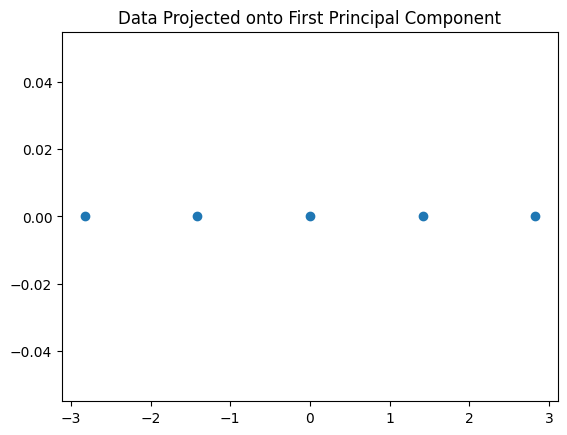

In [13]:
plt.scatter(
    projected_data,
    np.zeros_like(projected_data)
)

plt.title(
    "Data Projected onto First Principal Component"
)

plt.show()

## Applications in Machine Learning

PCA is widely applied in:

- Feature Selection
- Data Compression
- Noise Reduction
- Face Recognition
- Computer Vision
- Exploratory Data Analysis

It is one of the most commonly used dimensionality reduction techniques.

## Machine Learning Connection

Reducing the number of features can improve model performance, reduce training time, and decrease the risk of overfitting.

PCA is frequently used as a preprocessing step before model training.

In [14]:
print(
    "Principal Components:"
)

print(
    pca.components_
)

print(
    "\nExplained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

Principal Components:
[[-0.70710678 -0.70710678]]

Explained Variance Ratio:
[1.]


## Key Takeaways

- PCA reduces dimensionality while preserving important information.
- Principal components are derived from eigenvectors.
- Explained variance measures component importance.
- PCA improves efficiency and visualization.
- PCA is widely used in machine learning workflows.

## Discussion

PCA provides an effective method for simplifying complex datasets while retaining meaningful information.

By focusing on directions of maximum variance, PCA enables efficient analysis, visualization, and machine learning model development.

## Conclusion

This chapter introduced Principal Component Analysis (PCA), including covariance matrices, eigenvectors, explained variance, projection, reconstruction, and dimensionality reduction.

PCA demonstrates how linear algebra concepts such as eigendecomposition and SVD can be applied to real-world machine learning problems.

With PCA, the book concludes by connecting theoretical linear algebra concepts to practical data science and machine learning applications.